## Sree Ram Roshan A S - 24BAD113

In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
print("GPU devices:")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU is available:", gpus)
else:
    print("GPU is not available. Using CPU.")

GPU devices:
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os

print("Files in /content:")

for file in os.listdir("/content"):
    print(file)

Files in /content:
.config
archive.zip
sample_data


In [5]:
zip_path = "/content/archive.zip"
extract_path = "/content/cats_dogs"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
DATASET_PATH = "/content/cats_dogs/archive"

print("Dataset path:", DATASET_PATH)
print("Folders:", os.listdir(DATASET_PATH))

Dataset path: /content/cats_dogs/archive
Folders: ['cats_set', 'dogs_set']


In [7]:
cat_folder = os.path.join(DATASET_PATH, "cats_set")
dog_folder = os.path.join(DATASET_PATH, "dogs_set")

cat_images = [
    f for f in os.listdir(cat_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

dog_images = [
    f for f in os.listdir(dog_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of cat images:", len(cat_images))
print("Number of dog images:", len(dog_images))
print("Total images:", len(cat_images) + len(dog_images))

Number of cat images: 500
Number of dog images: 500
Total images: 1000


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 1000 files belonging to 2 classes.
Using 700 files for training.
Found 1000 files belonging to 2 classes.
Using 300 files for validation.
Classes: ['cats_set', 'dogs_set']
Number of classes: 2


In [9]:
temp_batches = tf.data.experimental.cardinality(temp_dataset).numpy()

test_batches = temp_batches // 2

test_dataset = temp_dataset.take(test_batches)
validation_dataset = temp_dataset.skip(test_batches)

print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())

print("Testing batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 44
Validation batches: 10
Testing batches: 9


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

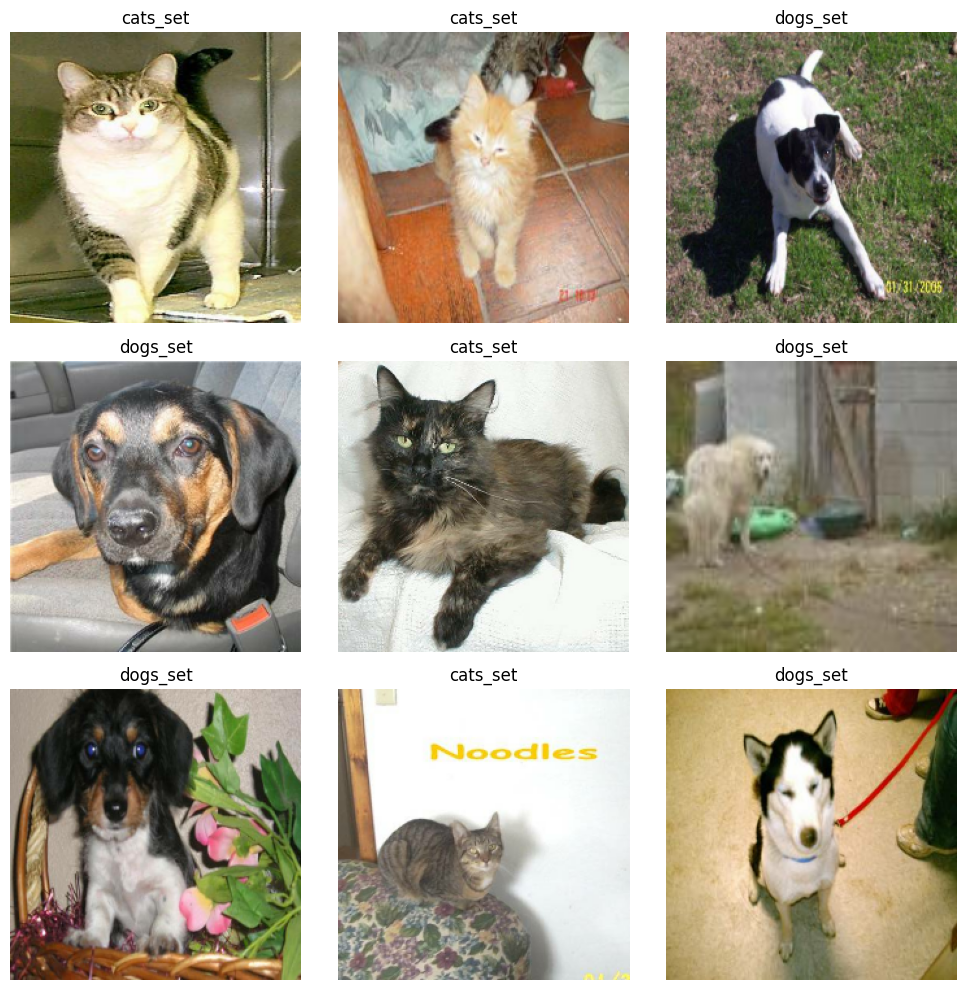

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet-50 loaded successfully.


In [13]:
base_model.trainable = False

print("Total ResNet-50 layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Total ResNet-50 layers: 175
Trainable: False


In [14]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [16]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 343ms/step - accuracy: 0.7929 - loss: 0.4312 - val_accuracy: 0.9615 - val_loss: 0.1440
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9500 - loss: 0.1596 - val_accuracy: 0.9744 - val_loss: 0.0990
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9714 - loss: 0.1030 - val_accuracy: 0.9744 - val_loss: 0.0986
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9786 - loss: 0.0908 - val_accuracy: 0.9744 - val_loss: 0.0714
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9808 - val_loss: 0.0808
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9843 - loss: 0.0501 - val_accuracy: 0.9679 - val_loss: 0.0832
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9871 - loss: 0.0405 - val_accuracy: 0.9744 - val_loss: 0.0794
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9943 - loss: 0.0329 - val_accuracy: 0.9808 -

In [17]:
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

print("Final Training Accuracy:",
      train_accuracy[-1])

print("Final Validation Accuracy:",
      val_accuracy[-1])

print("Final Training Loss:",
      train_loss[-1])

print("Final Validation Loss:",
      val_loss[-1])

Final Training Accuracy: 0.9942857027053833
Final Validation Accuracy: 0.9807692170143127
Final Training Loss: 0.022144362330436707
Final Validation Loss: 0.050091832876205444


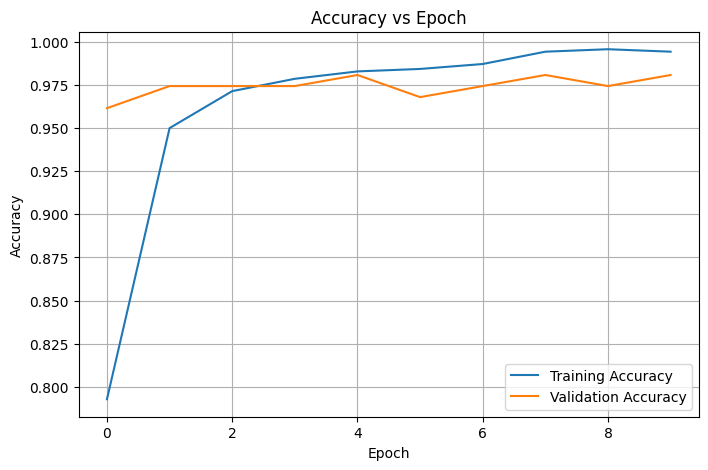

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()
plt.grid()

plt.show()

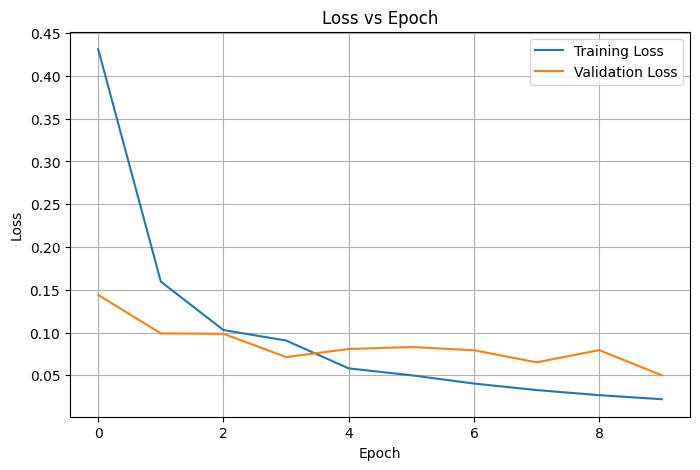

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss,
    label="Training Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()
plt.grid()

plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9861 - loss: 0.0555
Test Loss: 0.05553697794675827
Test Accuracy: 0.9861111044883728


In [21]:
print("TRANSFER LEARNING RESULTS")

print("Training Accuracy   :", round(train_accuracy[-1], 4))
print("Validation Accuracy :", round(val_accuracy[-1], 4))
print("Training Loss       :", round(train_loss[-1], 4))
print("Validation Loss     :", round(val_loss[-1], 4))
print("Test Accuracy       :", round(test_accuracy, 4))
print("Test Loss           :", round(test_loss, 4))

TRANSFER LEARNING RESULTS
Training Accuracy   : 0.9943
Validation Accuracy : 0.9808
Training Loss       : 0.0221
Validation Loss     : 0.0501
Test Accuracy       : 0.9861
Test Loss           : 0.0555


In [22]:
#Fine Tuning

base_model.trainable = True

# Freeze the first 140 layers
for layer in base_model.layers[:140]:
    layer.trainable = False

# Unfreeze the remaining layers
for layer in base_model.layers[140:]:
    layer.trainable = True

print("Fine-tuning enabled.")

Fine-tuning enabled.


In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [24]:
FINE_TUNE_EPOCHS = 5

fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - accuracy: 0.9586 - loss: 0.1038 - val_accuracy: 0.9808 - val_loss: 0.0542
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.9800 - loss: 0.0564 - val_accuracy: 0.9808 - val_loss: 0.0480
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9936 - val_loss: 0.0395
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9971 - loss: 0.0217 - val_accuracy: 0.9936 - val_loss: 0.0409
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9943 - loss: 0.0321 - val_accuracy: 0.9936 - val_loss: 0.0383


In [25]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_dataset)

print("Fine-tuned Test Loss:",
      fine_test_loss)

print("Fine-tuned Test Accuracy:",
      fine_test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9861 - loss: 0.0464
Fine-tuned Test Loss: 0.0464307926595211
Fine-tuned Test Accuracy: 0.9861111044883728


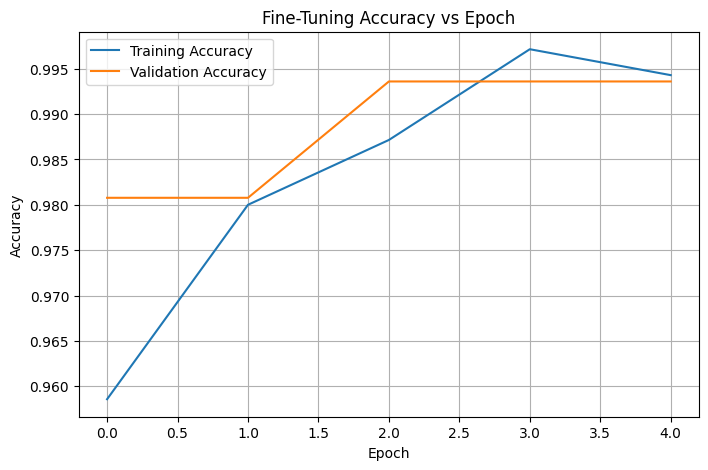

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Fine-Tuning Accuracy vs Epoch")

plt.legend()
plt.grid()

plt.show()

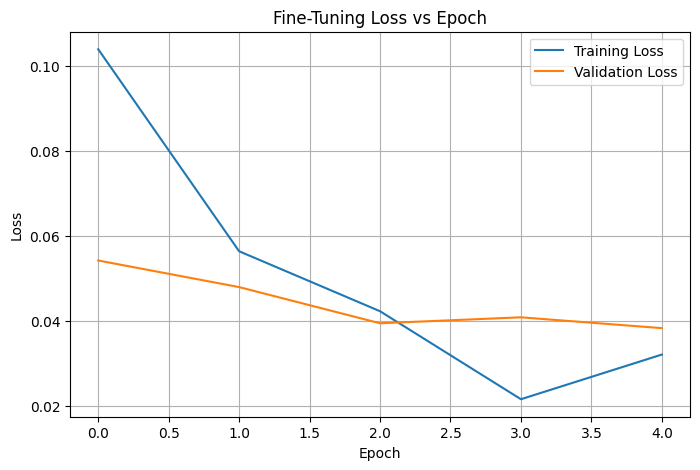

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Fine-Tuning Loss vs Epoch")

plt.legend()
plt.grid()

plt.show()

In [28]:
import random

cat_test_image = os.path.join(
    cat_folder,
    random.choice(cat_images)
)

dog_test_image = os.path.join(
    dog_folder,
    random.choice(dog_images)
)

print("Cat image:", cat_test_image)
print("Dog image:", dog_test_image)

Cat image: /content/cats_dogs/archive/cats_set/cat.4005.jpg
Dog image: /content/cats_dogs/archive/dogs_set/dog.4122.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


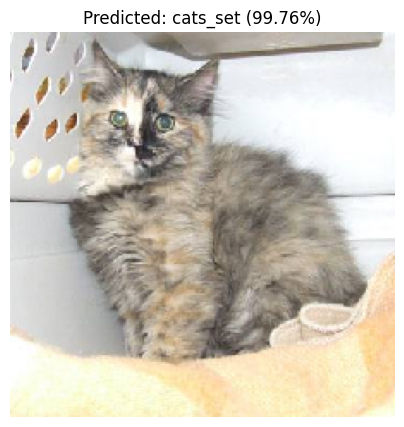

Predicted Class: cats_set
Confidence: 99.76 %


In [29]:
IMAGE_PATH = cat_test_image

img = tf.keras.utils.load_img(
    IMAGE_PATH,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.title(
    f"Predicted: {predicted_class} "
    f"({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Hugging face

In [30]:
!pip install -q transformers

In [31]:
from transformers import pipeline

print("Hugging Face imported successfully.")

Hugging Face imported successfully.


In [32]:
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face Vision Transformer loaded successfully.")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Vision Transformer loaded successfully.


In [33]:
hf_results = classifier(IMAGE_PATH)

print("Hugging Face Predictions:")
print()

for result in hf_results[:5]:

    print(
        "Label:",
        result["label"],
        "| Confidence:",
        round(result["score"] * 100, 2),
        "%"
    )

Hugging Face Predictions:

Label: tabby, tabby cat | Confidence: 44.67 %
Label: hamper | Confidence: 19.81 %
Label: washer, automatic washer, washing machine | Confidence: 6.91 %
Label: Persian cat | Confidence: 3.69 %
Label: tiger cat | Confidence: 3.59 %


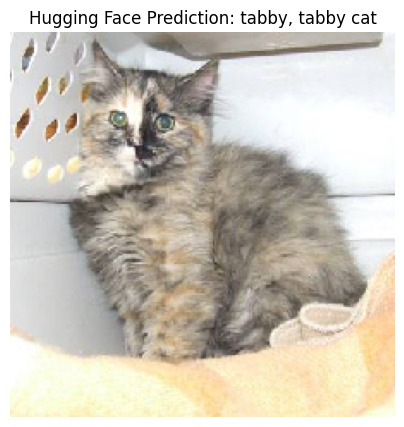

In [34]:
plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.title(
    f"Hugging Face Prediction: "
    f"{hf_results[0]['label']}"
)

plt.axis("off")

plt.show()

In [36]:
print("MODEL COMPARISON")

print("\nResNet-50 Transfer Learning")
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

print("\nHugging Face ViT")

for result in hf_results[:3]:

    print(
        result["label"],
        "->",
        round(result["score"] * 100, 2),
        "%"
    )


MODEL COMPARISON

ResNet-50 Transfer Learning
Predicted Class: cats_set
Confidence: 99.76 %

Hugging Face ViT
tabby, tabby cat -> 44.67 %
hamper -> 19.81 %
washer, automatic washer, washing machine -> 6.91 %


In [37]:
model.save(
    "/content/resnet50_cats_dogs_transfer_learning.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [38]:
print("EXPERIMENT 4 - FINAL RESULTS")

print("\nDataset")
print("Cats:", len(cat_images))
print("Dogs:", len(dog_images))
print("Total:", len(cat_images) + len(dog_images))

print("\nResNet-50 Transfer Learning")
print("Training Accuracy   :", round(train_accuracy[-1], 4))
print("Validation Accuracy :", round(val_accuracy[-1], 4))
print("Training Loss       :", round(train_loss[-1], 4))
print("Validation Loss     :", round(val_loss[-1], 4))
print("Initial Test Accuracy:", round(test_accuracy, 4))

print("\nAfter Fine-Tuning")
print("Fine-Tuned Test Accuracy:",
      round(fine_test_accuracy, 4))

print("\nSample Prediction")
print("ResNet-50:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

print("\nHugging Face")
print("Top Prediction:", hf_results[0]["label"])
print("Confidence:",
      round(hf_results[0]["score"] * 100, 2), "%")

EXPERIMENT 4 - FINAL RESULTS

Dataset
Cats: 500
Dogs: 500
Total: 1000

ResNet-50 Transfer Learning
Training Accuracy   : 0.9943
Validation Accuracy : 0.9808
Training Loss       : 0.0221
Validation Loss     : 0.0501
Initial Test Accuracy: 0.9861

After Fine-Tuning
Fine-Tuned Test Accuracy: 0.9861

Sample Prediction
ResNet-50: cats_set
Confidence: 99.76 %

Hugging Face
Top Prediction: tabby, tabby cat
Confidence: 44.67 %
